In [1]:
import sklearn 
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from itertools import combinations
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib import pyplot as plt

In [ ]:


def load_dataframe():
  path = "high_popularity_spotify_data.csv"
  df = pd.read_csv(path)
  return df

def preprocess_data(df):
  df = df.drop_duplicates(subset=['track_name','track_artist']) #deletes all row duplicates
  df = df.drop(['speechiness','instrumentalness','mode','duration_ms', 'acousticness','track_album_name','track_album_id','playlist_genre','time_signature','track_popularity','playlist_name','track_album_release_date','playlist_id','type', 'playlist_subgenre','analysis_url','track_href','uri','track_id','id'], axis=1) #delete the columns speechiness, liveness, artwork_url and mode
  df = df[~(df == -1).any(axis=1)] #deletes all entries with values that are -1 (not existent)

  # generate a new column track_id with values from 0 to len(dataframe)
  df['track_id'] = range(len(df))

  # set the track_id as the DataFrame index to standardize indexing
  df.set_index('track_id', inplace=True)
  return df


df = load_dataframe()
df = preprocess_data(df)
df = df[['danceability', 'energy', 'tempo', 'loudness', 'liveness', 'valence', 'key', 'track_name', 'track_artist']] #maybe noch rausnehmen

print("Energy Max und Min")
print(df['energy'].max())
print(df['energy'].min())
print("Tempo Max und Min")
print(df['tempo'].max())
print(df['tempo'].min())
print("Loudness Max und Min")
print(df['loudness'].max())
print(df['loudness'].min())
print("Liveness Max und Min")
print(df['liveness'].max())
print(df['liveness'].min())
print("Valence Max und Min")
print(df['valence'].max())
print(df['valence'].min())
print("Key Max und Min")
print(df['key'].max())
print(df['key'].min())

Energy Max und Min
0.99
0.00161
Tempo Max und Min
209.688
49.305
Loudness Max und Min
1.295
-43.643
Liveness Max und Min
0.95
0.021
Valence Max und Min
0.978
0.0348
Key Max und Min
11
0


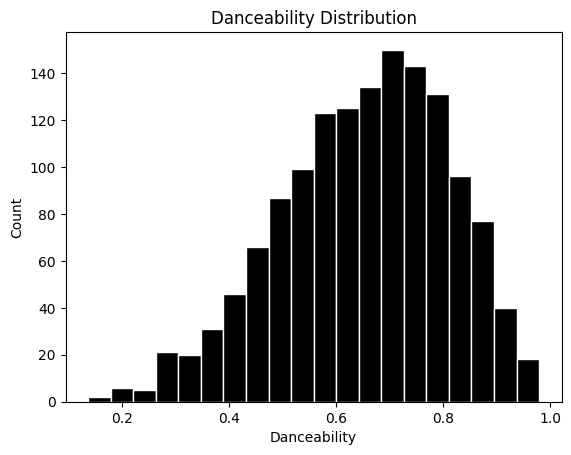

In [3]:
plt.hist(df['danceability'], bins=20, label='Danceability', color = 'black',edgecolor='white')
plt.title('Danceability Distribution')
plt.xlabel('Danceability')
plt.ylabel('Count')
plt.show()

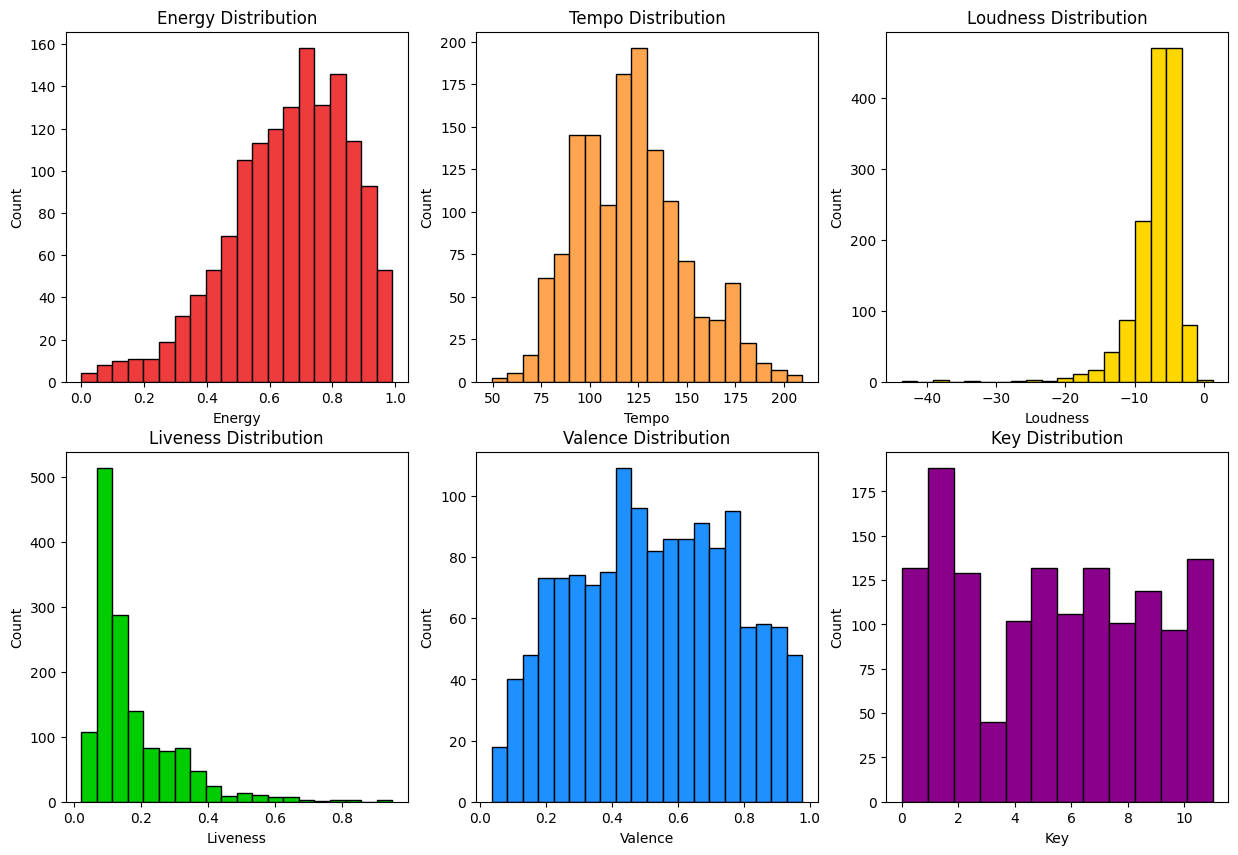

In [4]:
#featureverteilung plotten
#sechs subplots für die sechs Features erstellen
fig, ([[ax1,ax2,ax3],[ax4,ax5,ax6]]) = plt.subplots(2, 3, figsize=(15, 10))

ax1.hist(df['energy'], bins=20, edgecolor = 'black', color= '#EE3B3B')
ax1.title.set_text('Energy Distribution')
ax1.set_xlabel('Energy')
ax1.set_ylabel('Count')

ax2.hist(df['tempo'], bins=20, edgecolor = 'black',color='#FFA54F')
ax2.title.set_text('Tempo Distribution')
ax2.set_xlabel('Tempo')
ax2.set_ylabel('Count')

ax3.hist(df['loudness'], bins=20,edgecolor = 'black',color='#FFD700')
ax3.title.set_text('Loudness Distribution')
ax3.set_xlabel('Loudness')
ax3.set_ylabel('Count')

ax4.hist(df['liveness'], bins=20,edgecolor = 'black',color = '#00CD00')
ax4.title.set_text('Liveness Distribution')
ax4.set_xlabel('Liveness')
ax4.set_ylabel('Count')

ax5.hist(df['valence'], bins=20,edgecolor = 'black',color='#1E90FF')
ax5.title.set_text('Valence Distribution')
ax5.set_xlabel('Valence')
ax5.set_ylabel('Count')

ax6.hist(df['key'], bins=12,edgecolor = 'black',color = '#8B008B')
ax6.title.set_text('Key Distribution')
ax6.set_xlabel('Key')
ax6.set_ylabel('Count')
plt.show()

In [5]:
print(df.head())

          danceability  energy    tempo  loudness  liveness  valence  key  \
track_id                                                                    
0                0.521   0.592  157.969    -7.777     0.122    0.535    6   
1                0.747   0.507  104.978   -10.171     0.117    0.438    2   
2                0.554   0.808  108.548    -4.169     0.159    0.372    1   
3                0.670   0.910  112.966    -4.070     0.304    0.786    0   
4                0.777   0.783  149.027    -4.477     0.355    0.939    0   

                  track_name           track_artist  
track_id                                             
0           Die With A Smile  Lady Gaga, Bruno Mars  
1         BIRDS OF A FEATHER          Billie Eilish  
2             That’s So True          Gracie Abrams  
3                      Taste      Sabrina Carpenter  
4                       APT.       ROSÉ, Bruno Mars  


In [14]:
scalar = StandardScaler()

#Training und Testdataset
train, test = sklearn.model_selection.train_test_split(df, test_size=0.2, random_state=42)
relevant_features = ['energy', 'tempo', 'loudness', 'liveness', 'valence', 'key']
x_train = scalar.fit_transform(train[relevant_features])
x_test = scalar.transform(test[relevant_features])
y_train = train['danceability']
y_test = test['danceability']

data = [] #alle Kombinationen an relevanten features
for r in range (1,len(relevant_features)+1):
    for elem in combinations(relevant_features, r):
        data.append(elem)
        
#model
model = MLPRegressor(hidden_layer_sizes=(64,64,32,16), activation='relu', solver='adam', max_iter=2000, random_state=42)
best_three_r2 = [[0,0,0], [0,0,0], [0,0,0]]
worst_three_r2 = [[1,1,1], [1,1,1], [1,1,1]]

#train the model
for elem in data:
    x_train_subset = x_train[:, [relevant_features.index(feature) for feature in elem]]
    x_test_subset = x_test[:, [relevant_features.index(feature) for feature in elem]]
    model.fit(x_train_subset, y_train)
    y_pred = model.predict(x_test_subset)
    
    #Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    elem = [elem, r2, mse]

    #best three combinations of features based on r2 score
    if r2 > best_three_r2[2][1]:
        if r2 > best_three_r2[1][1]:
            if r2 > best_three_r2[0][1]:
                best_three_r2[2][1] = best_three_r2[1][1]
                best_three_r2[1][1] = best_three_r2[0][1]
                best_three_r2[0] = elem
            else:
                best_three_r2[2][1] = best_three_r2[1][1]
                best_three_r2[1] = elem
        else:
            best_three_r2[2] = elem


    #worst three combinations of features based on r2 score
    if r2 < worst_three_r2[2][1]:
        if r2 < worst_three_r2[1][1]:
            if r2 < worst_three_r2[0][1]:
                worst_three_r2[2][1] = worst_three_r2[1][1]
                worst_three_r2[1][1] = worst_three_r2[0][1]
                worst_three_r2[0] = elem
            else:
                worst_three_r2[2][1] = worst_three_r2[1][1]
                worst_three_r2[1] = elem
        else:
            worst_three_r2[2] = elem

print('Best feature combinations')
for elem in best_three_r2:
    print(f"Features: {elem[0]}, R2: {elem[1]}, MSE: {elem[2]}")
print('worst feature combinations')
for elem in worst_three_r2:
    print(f"Features: {elem[0]}, R2: {elem[1]}, MSE: {elem[2]}")
summary = worst_three_r2 + best_three_r2[::-1]

Best feature combinations
Features: ('energy', 'tempo', 'loudness', 'valence', 'key'), R2: 0.29687219278005206, MSE: 0.017037259010761956
Features: ('energy', 'tempo', 'valence', 'key'), R2: 0.29063520953125543, MSE: 0.017777806387225405
Features: ('energy', 'liveness'), R2: 0.2798334671077132, MSE: 0.019890524195511253
worst feature combinations
Features: ('key',), R2: -0.010197674009890134, MSE: 0.0244777681204577
Features: ('liveness', 'key'), R2: 0.0041254573763214175, MSE: 0.024130709027123158
Features: ('tempo', 'liveness', 'key'), R2: 0.01306735555222538, MSE: 0.023914040828672746


We tested the plotting based on both scores (MSE and R2) and figured out that they are interacting such that the combinations with the worst MSE also have the worst R2 score. We therefore decided to base our analysis on only R2 for better overview.

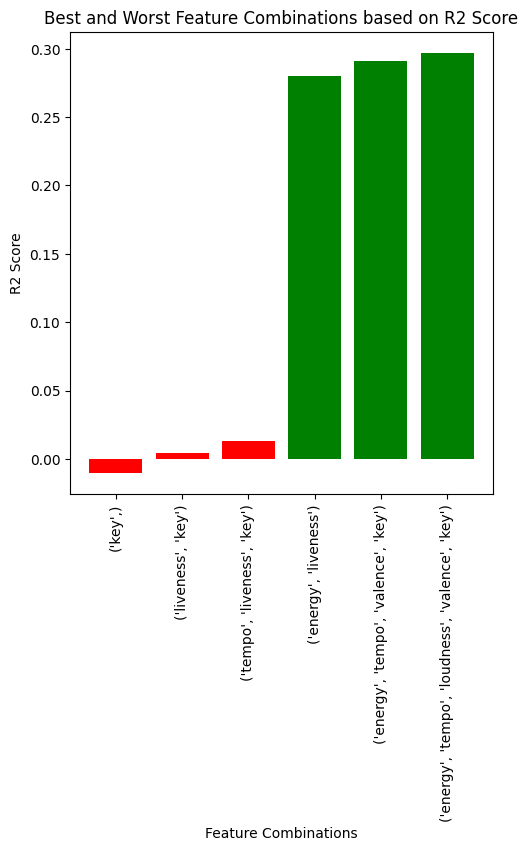

In [15]:
#plotting bar-charts for best and worst R2
plt.figure(figsize=(12, 6))
ax1 = plt.subplot(1, 2, 1)
ax1.bar(range(len(summary)), 
        [elem[1] for elem in summary], 
        tick_label=[str(elem[0]) for elem in summary], 
        color=['red','red','red','green','green','green'])
ax1.set_xlabel('Feature Combinations')
ax1.tick_params(axis='x', rotation=90)
ax1.set_ylabel('R2 Score')
plt.title('Best and Worst Feature Combinations based on R2 Score')
plt.plot()
plt.show()

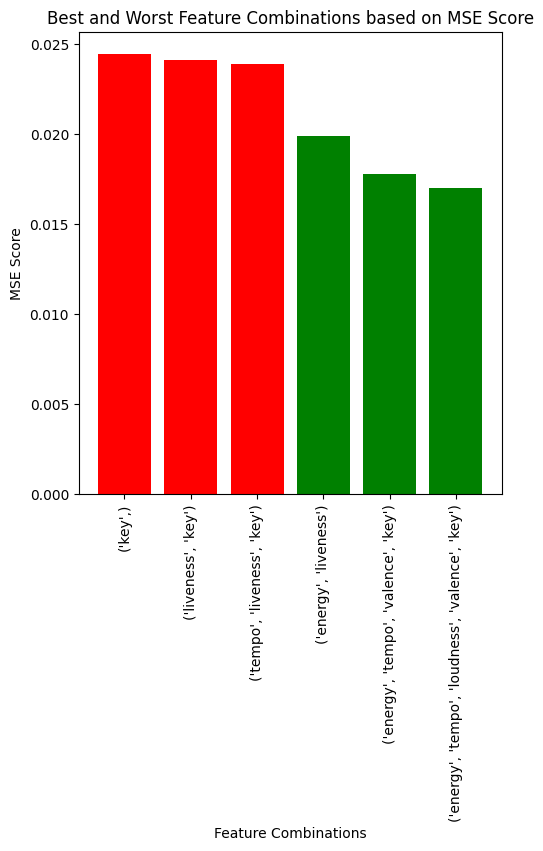

In [16]:
#plotting bar-charts for best and worst MSE 
plt.figure(figsize=(12, 6))
ax1 = plt.subplot(1, 2, 1)
ax1.bar(range(len(summary)), 
        [elem[2] for elem in summary], 
        tick_label=[str(elem[0]) for elem in summary], 
        color=['red','red','red','green','green','green'])
ax1.set_xlabel('Feature Combinations')
ax1.tick_params(axis='x', rotation=90)
ax1.set_ylabel('MSE Score')
plt.title('Best and Worst Feature Combinations based on MSE Score')
plt.plot()
plt.show()